<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Tw_ML_Predicting_Employee_Burnout_with_Regression/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis (EDA)

## Data Source:
https://huggingface.co/datasets/BrotherTony/employee-burnout-turnover-prediction-800k

## Overview:
The goal of this phase is to visually investigate the patterns and correlations within our optimized dataset. By utilizing statistical plots, we aim to validate our feature engineering decisions and identify the strongest drivers of employee burnout. This stage provides the "Why" behind the numbers before we move to the predictive modeling phase.

## Quick Information (from dataset website):
- Total Records 800,000+
- Departments 38 unique divisions
- Job Roles 300+ distinct positions
- Employee Personas 12 behavioral archetypes
- Features per Record 30+ attributes
- Salary Range 27k -384K


In [3]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# تحسين شكل الرسومات
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
url = "https://huggingface.co/datasets/BrotherTony/employee-burnout-turnover-prediction-800k/resolve/main/synthetic-employee-dataset.json"
df = pd.read_json(url)

In [5]:
print("First 5 rows:")
print(df.head())

print("\nData Info:")
print(df.info())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

First 5 rows:
    employee_id                       role job_level              department  \
0  SYN_00000000                                  Mid  Research & Development   
1  SYN_00000001   Customer Success Manager   Manager  Research & Development   
2  SYN_00000002   Administrative Assistant     Entry                      HR   
3  SYN_00000003             Senior Manager   Manager  Research & Development   
4  SYN_00000004         Anonymous Employee       Mid  Research & Development   

   tenure_months         salary  performance_score  satisfaction_score  \
0            169   79704.579059           0.632482            0.623746   
1             54   29694.288831           0.538587            0.982556   
2              1   62208.470185           0.624656            0.767200   
3             31  236066.567114           0.959320            0.185888   
4            131   37306.328156           0.677305            0.566706   

   workload_score  team_sentiment  ... goal_achievement_rate

In [8]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,collaboration_score,email_sentiment,slack_activity,meeting_participation,goal_achievement_rate,stress_level,burnout_risk,turnover_probability_generated,role_complexity_score,career_progression_score
count,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000,849999.000000
mean,70.380999,84563.069751,0.692027,0.581941,0.599490,0.666848,0.595412,3.132903,0.279344,0.473380,0.582392,0.473380,0.473380,0.692027,0.791048,0.735941,0.285327,0.210859,0.841147
std,50.177033,47444.308564,0.183911,0.276268,0.200038,0.178232,0.161173,6.094207,0.221602,0.184961,0.277255,0.184961,0.184961,0.183911,0.264536,0.315756,0.087902,0.085018,0.182216
min,1.000000,27190.569289,0.074113,0.050000,0.006741,0.019774,0.059290,0.000000,0.000079,0.008674,0.042500,0.008674,0.008674,0.074113,0.000000,0.000000,0.131127,0.200000,0.182198
25%,30.000000,41006.776951,0.571340,0.367016,0.455657,0.545729,0.490179,0.000000,0.103691,0.332366,0.367212,0.332366,0.332366,0.571340,0.613005,0.479950,0.227733,0.200000,0.713997
50%,67.000000,78178.525918,0.699235,0.583188,0.613744,0.686320,0.609499,0.000000,0.223123,0.457102,0.583141,0.457102,0.457102,0.699235,0.942151,0.914494,0.299657,0.200000,0.911793
75%,105.000000,116146.639606,0.825585,0.813912,0.756693,0.806540,0.716149,4.161240,0.400716,0.600885,0.811581,0.600885,0.600885,0.825585,1.000000,1.000000,0.335272,0.200000,1.000000
max,357.000000,384330.428656,1.000000,1.000000,0.999615,0.999956,1.000000,73.953574,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.899983,1.000000,1.000000


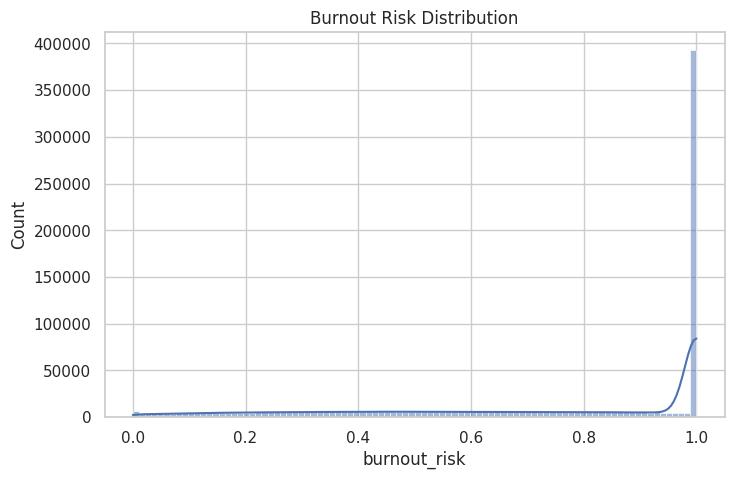

In [7]:
plt.figure()
sns.histplot(df["burnout_risk"], kde=True)
plt.title("Burnout Risk Distribution")
plt.xlabel("burnout_risk")
plt.ylabel("Count")
plt.show()

> #### A noticeable concentration of higher burnout values suggests that a considerable number of employees may be experiencing elevated work-related strain.




---

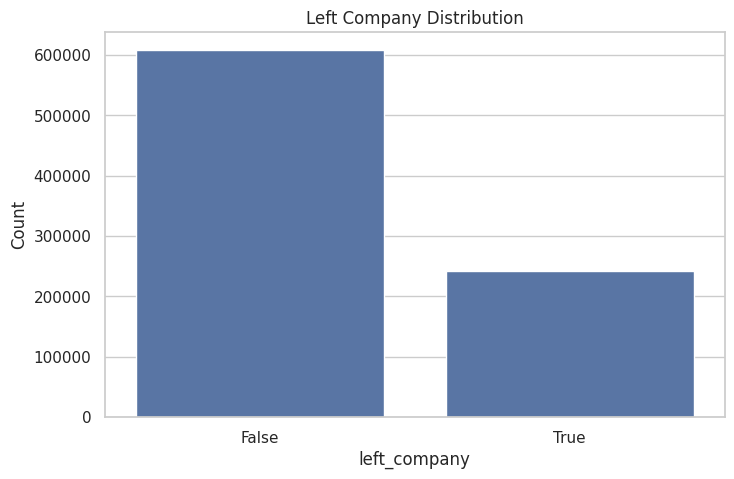

In [9]:
plt.figure()
sns.countplot(x="left_company", data=df)
plt.title("Left Company Distribution")
plt.xlabel("left_company")
plt.ylabel("Count")
plt.show()

In [10]:
numeric_cols = [
    'tenure_months',
    'salary',
    'performance_score',
    'satisfaction_score',
    'workload_score',
    'team_sentiment',
    'project_completion_rate',
    'overtime_hours',
    'training_participation',
    'collaboration_score',
    'email_sentiment',
    'slack_activity',
    'meeting_participation',
    'goal_achievement_rate',
    'stress_level',
    'burnout_risk',
    'role_complexity_score',
    'career_progression_score'
]


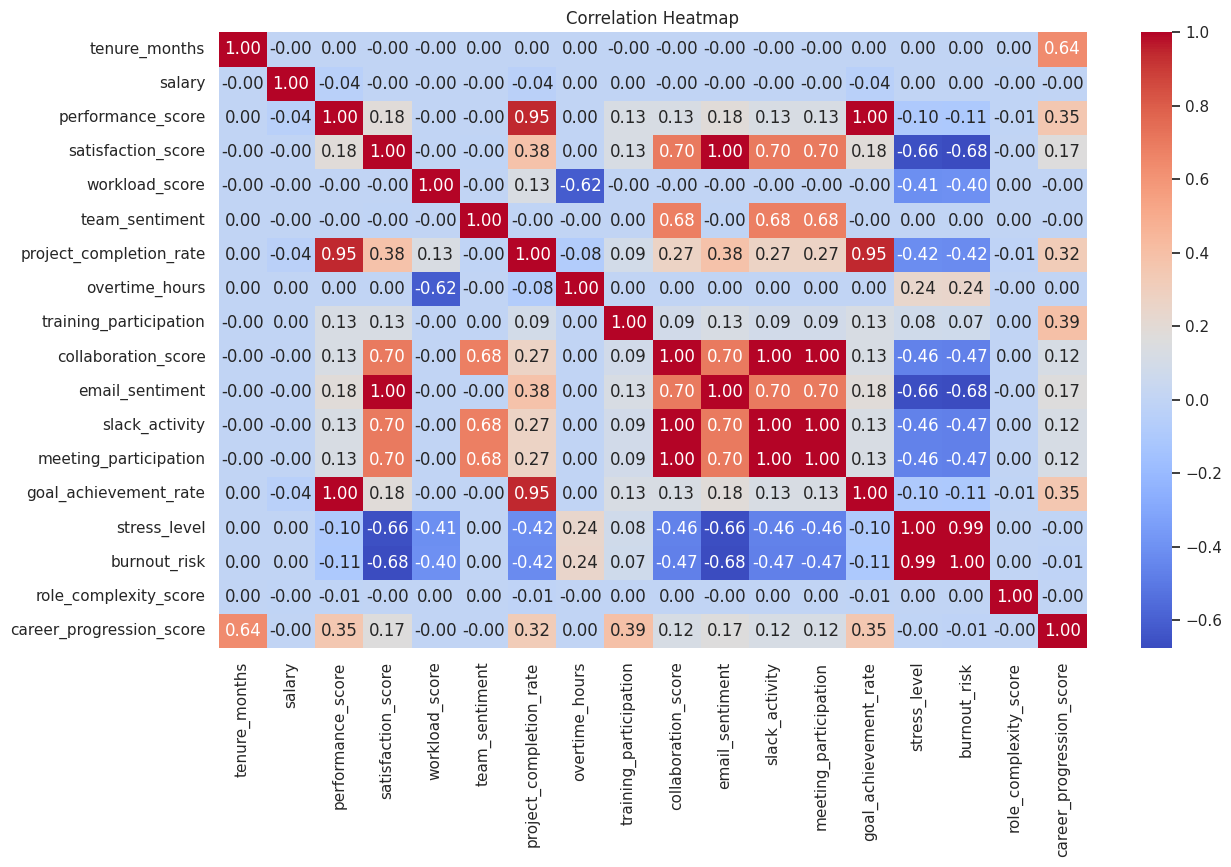

In [11]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


>#### The correlation heatmap provides an overall view of how numeric variables relate to each other, helping identify strong positive or negative relationships.

In [12]:
burnout_features = [
    'tenure_months',
    'salary',
    'performance_score',
    'satisfaction_score',
    'workload_score',
    'team_sentiment',
    'project_completion_rate',
    'overtime_hours',
    'training_participation',
    'collaboration_score',
    'email_sentiment',
    'slack_activity',
    'meeting_participation',
    'goal_achievement_rate',
    'stress_level',
    'role_complexity_score',
    'career_progression_score'
]

burnout_corr = df[burnout_features + ['burnout_risk']].corr()['burnout_risk'].sort_values(ascending=False)

print("\nCorrelation with Burnout Risk:")
print(burnout_corr)

print("\nTop Positive Factors Increasing Burnout:")
print(burnout_corr[burnout_corr > 0].sort_values(ascending=False))

print("\nTop Negative Factors Reducing Burnout:")
print(burnout_corr[burnout_corr < 0].sort_values())


Correlation with Burnout Risk:
burnout_risk                1.000000
stress_level                0.994221
overtime_hours              0.240957
training_participation      0.072186
role_complexity_score       0.004662
team_sentiment              0.002773
salary                      0.000589
tenure_months               0.000535
career_progression_score   -0.011056
performance_score          -0.106267
goal_achievement_rate      -0.106267
workload_score             -0.403526
project_completion_rate    -0.423375
collaboration_score        -0.471630
meeting_participation      -0.471630
slack_activity             -0.471630
satisfaction_score         -0.675306
email_sentiment            -0.676294
Name: burnout_risk, dtype: float64

Top Positive Factors Increasing Burnout:
burnout_risk              1.000000
stress_level              0.994221
overtime_hours            0.240957
training_participation    0.072186
role_complexity_score     0.004662
team_sentiment            0.002773
salary         

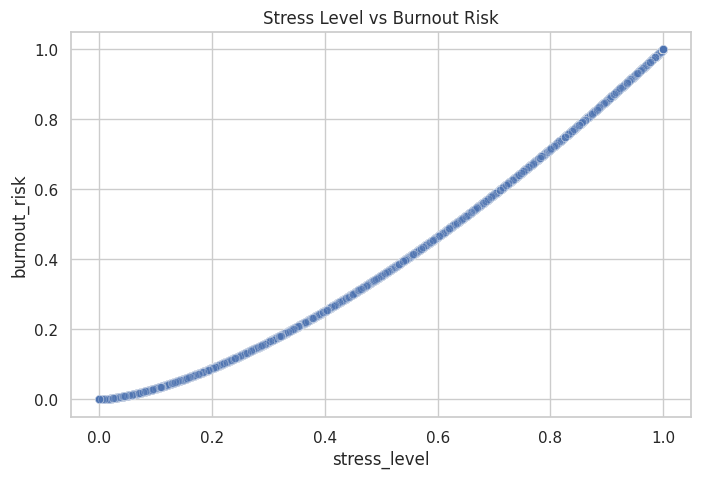

In [13]:
plt.figure()
sns.scatterplot(x="stress_level", y="burnout_risk", data=df, alpha=0.3)
plt.title("Stress Level vs Burnout Risk")
plt.show()

>#### Stress level appears to be one of the strongest positive indicators of burnout risk.

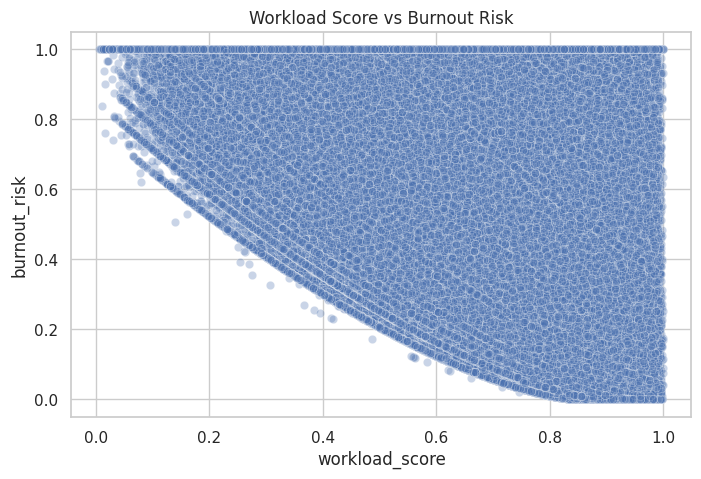

In [14]:
plt.figure()
sns.scatterplot(x="workload_score", y="burnout_risk", data=df, alpha=0.3)
plt.title("Workload Score vs Burnout Risk")
plt.show()

>#### A higher workload score is strongly associated with increased burnout risk.

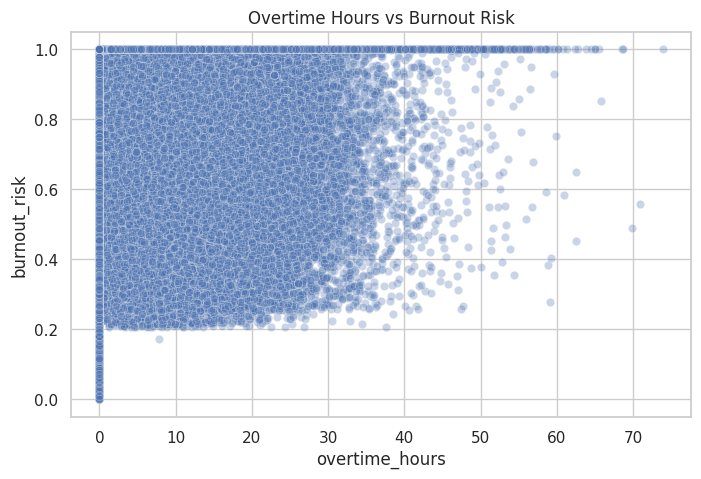

In [15]:
plt.figure()
sns.scatterplot(x="overtime_hours", y="burnout_risk", data=df, alpha=0.3)
plt.title("Overtime Hours vs Burnout Risk")
plt.show()

>#### Employees with more overtime hours tend to have higher burnout risk.

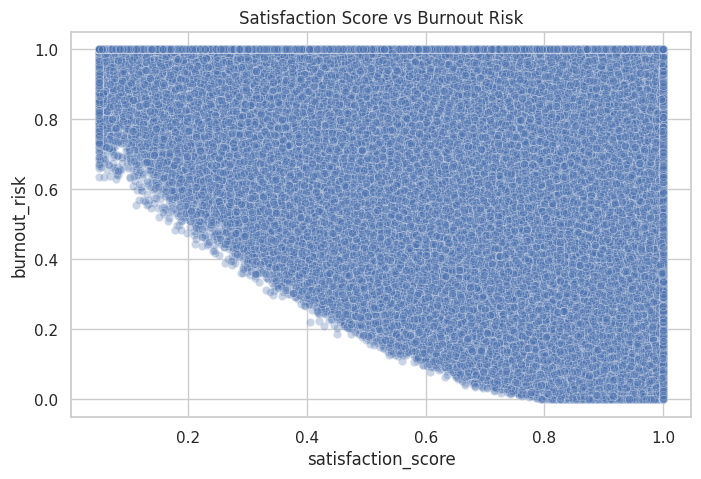

In [16]:
plt.figure()
sns.scatterplot(x="satisfaction_score", y="burnout_risk", data=df, alpha=0.3)
plt.title("Satisfaction Score vs Burnout Risk")
plt.show()

>#### Higher job satisfaction is associated with lower burnout risk.

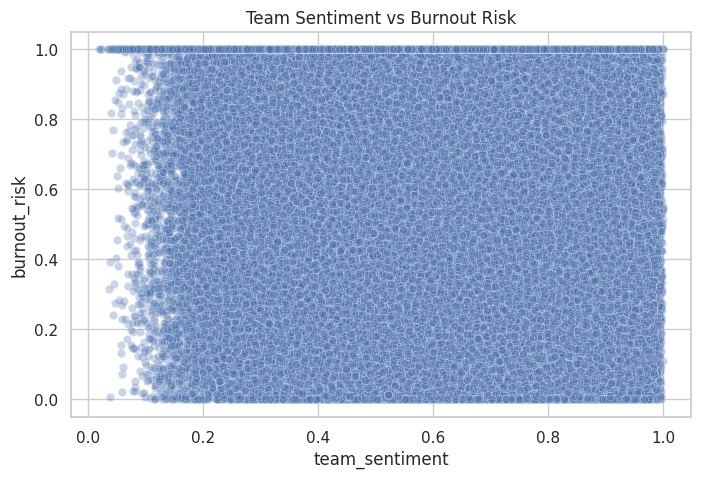

In [17]:
plt.figure()
sns.scatterplot(x="team_sentiment", y="burnout_risk", data=df, alpha=0.3)
plt.title("Team Sentiment vs Burnout Risk")
plt.show()

>#### A more positive team environment is linked to lower burnout levels.

In [18]:
df["left_company_num"] = df["left_company"].astype(int)

turnover_corr = df[burnout_features + ['left_company_num']].corr()['left_company_num'].sort_values(ascending=False)

print("\nCorrelation with Left Company:")
print(turnover_corr)


Correlation with Left Company:
left_company_num            1.000000
stress_level                0.114824
overtime_hours              0.018476
role_complexity_score       0.002314
salary                     -0.000169
tenure_months              -0.000619
team_sentiment             -0.000938
training_participation     -0.001323
career_progression_score   -0.010760
performance_score          -0.019992
goal_achievement_rate      -0.019992
workload_score             -0.032296
project_completion_rate    -0.055943
collaboration_score        -0.077866
meeting_participation      -0.077866
slack_activity             -0.077866
email_sentiment            -0.110006
satisfaction_score         -0.110051
Name: left_company_num, dtype: float64


>#### The correlation heatmap provides an overall view of how numeric variables relate to each other, helping identify strong positive or negative relationships.

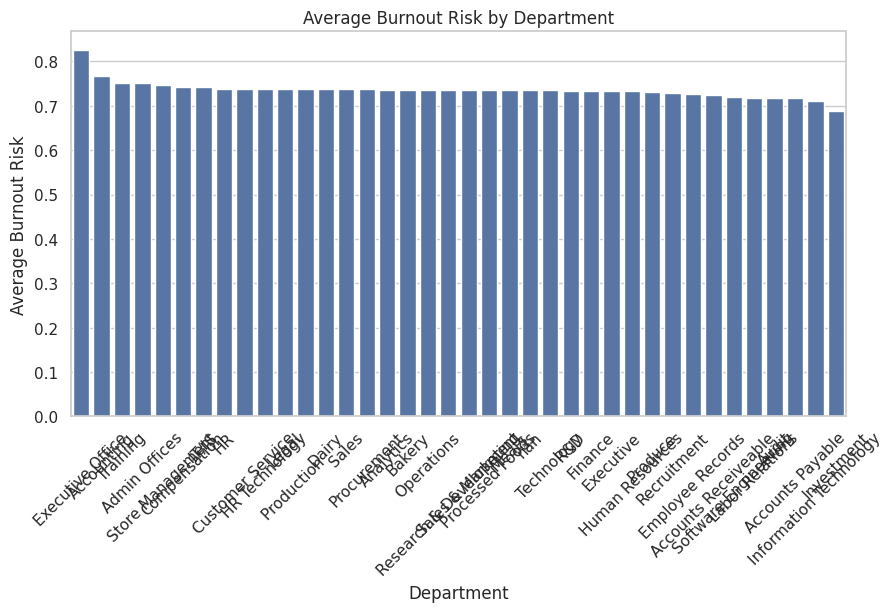

In [24]:
dept_burnout = df.groupby("department")["burnout_risk"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_burnout.index, y=dept_burnout.values)
plt.title("Average Burnout Risk by Department")
plt.xlabel("Department")
plt.ylabel("Average Burnout Risk")
plt.xticks(rotation=45)
plt.show()

>#### Burnout levels vary by department, indicating that workplace pressure may differ depending on the nature of the department.

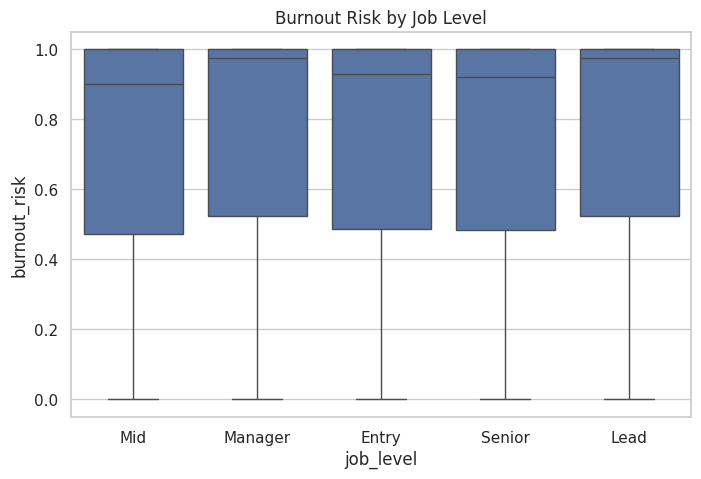

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="job_level", y="burnout_risk", data=df)
plt.title("Burnout Risk by Job Level")
plt.show()

>#### Burnout risk differs across job levels, suggesting that seniority or responsibility may influence employee strain.

In [26]:
important_numeric = [
    'salary',
    'satisfaction_score',
    'workload_score',
    'overtime_hours',
    'stress_level',
    'career_progression_score'
]

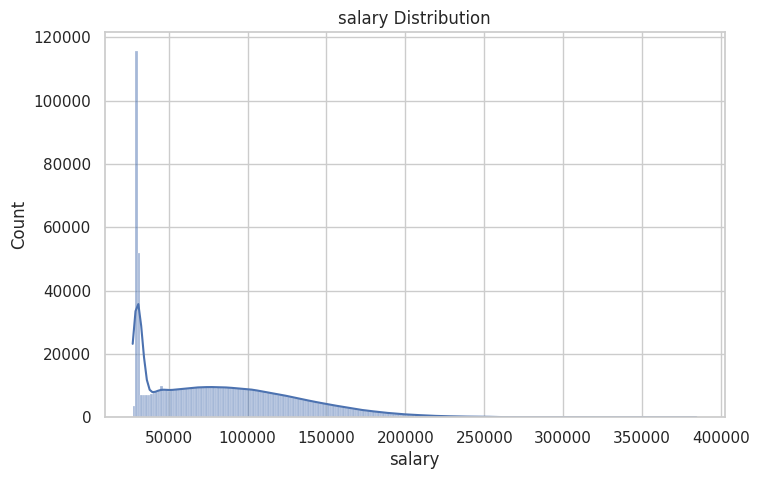

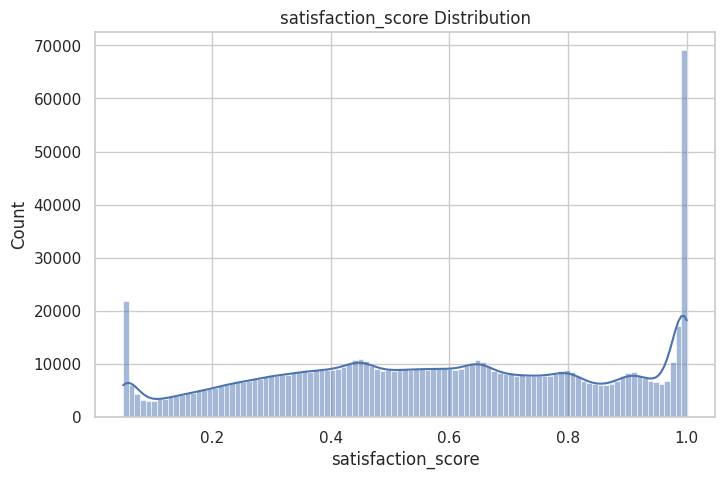

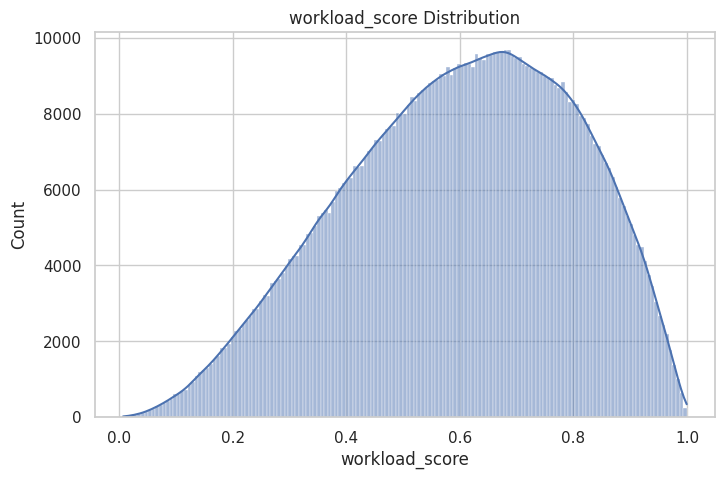

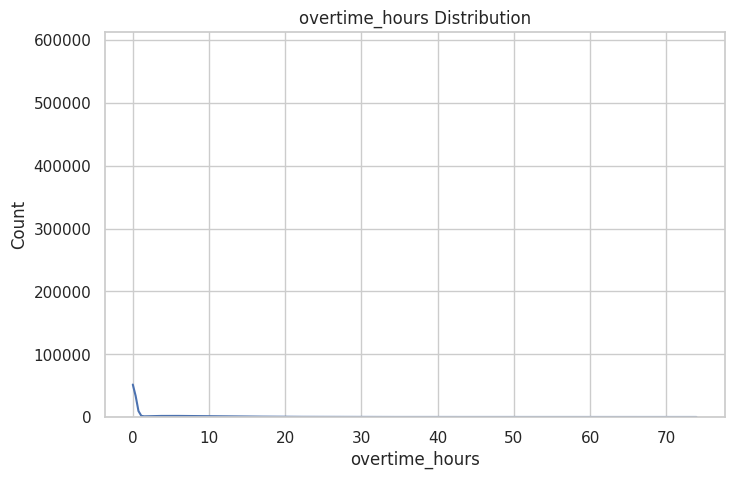

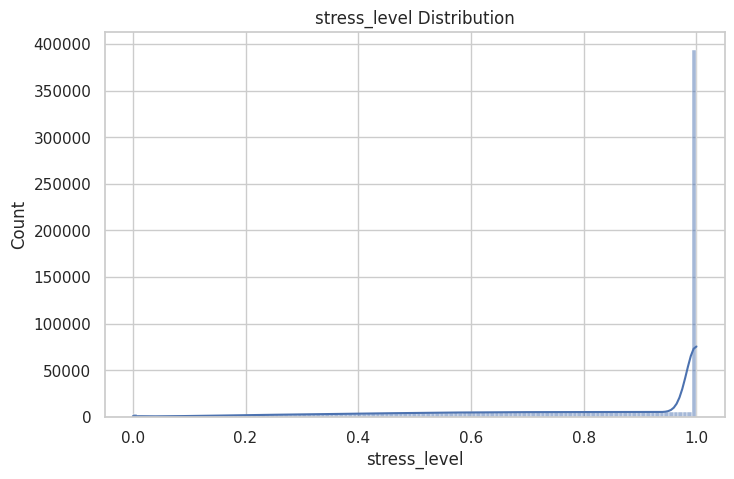

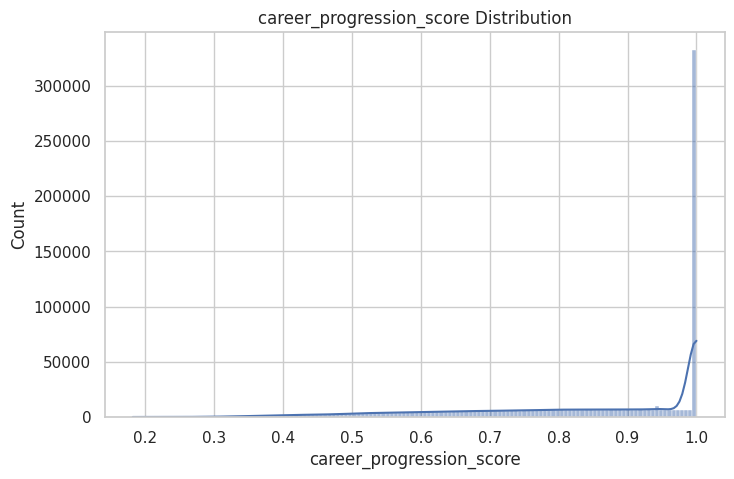

In [27]:
for col in important_numeric:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


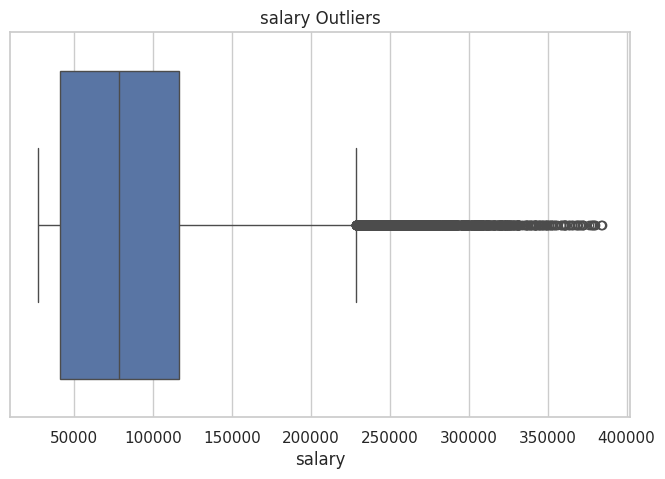

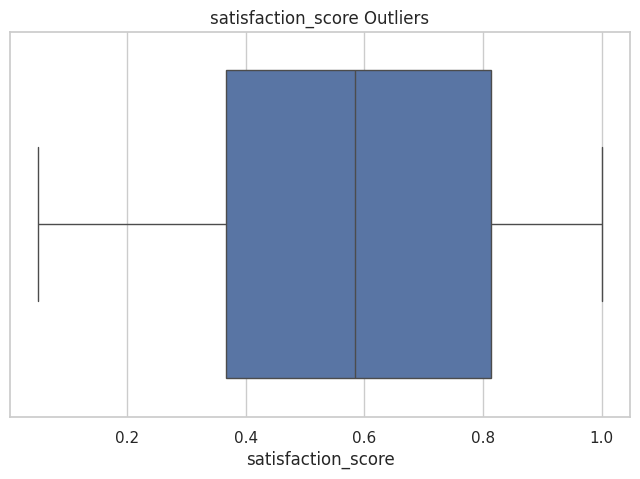

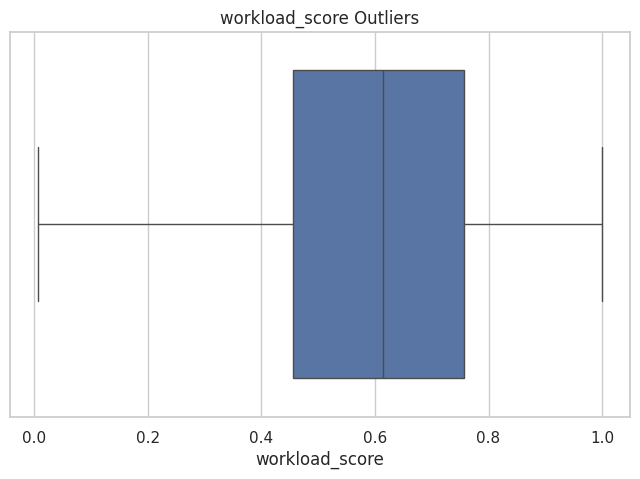

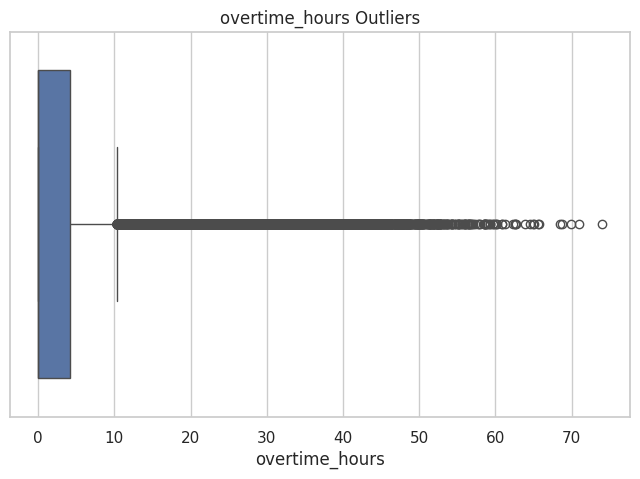

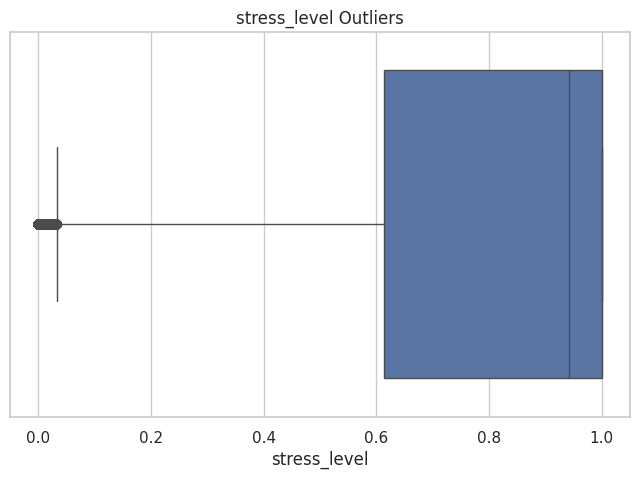

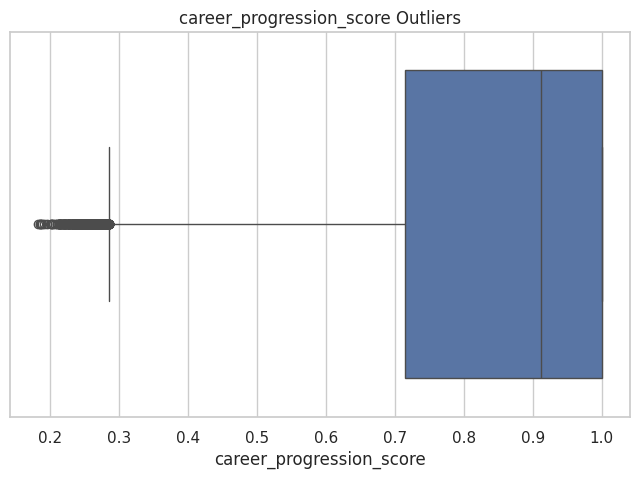

In [28]:
for col in important_numeric:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"{col} Outliers")
    plt.show()

In [29]:
important_features = [
    'stress_level',
    'workload_score',
    'overtime_hours',
    'satisfaction_score',
    'team_sentiment',
    'project_completion_rate',
    'collaboration_score',
    'goal_achievement_rate',
    'career_progression_score',
    'role_complexity_score',
    'salary',
    'tenure_months',
    'training_participation'
]

print("\nSuggested Important Features for Model Training:")
print(important_features)



Suggested Important Features for Model Training:
['stress_level', 'workload_score', 'overtime_hours', 'satisfaction_score', 'team_sentiment', 'project_completion_rate', 'collaboration_score', 'goal_achievement_rate', 'career_progression_score', 'role_complexity_score', 'salary', 'tenure_months', 'training_participation']


In [30]:
print("\n================ FINAL INSIGHTS ================")
print("1. Higher stress_level, workload_score, and overtime_hours are expected to increase burnout risk.")
print("2. Higher satisfaction_score, team_sentiment, collaboration_score, and career_progression_score are expected to reduce burnout risk.")
print("3. Employees with higher burnout_risk are more likely to leave the company.")
print("4. Department and job_level may show differences in burnout and turnover patterns.")
print("5. The selected important_features can be used later for model training.")


================ FINAL INSIGHTS ================
1. Higher stress_level, workload_score, and overtime_hours are expected to increase burnout risk.
2. Higher satisfaction_score, team_sentiment, collaboration_score, and career_progression_score are expected to reduce burnout risk.
3. Employees with higher burnout_risk are more likely to leave the company.
4. Department and job_level may show differences in burnout and turnover patterns.
5. The selected important_features can be used later for model training.
